Running simulations...


100%|██████████| 6/6 [00:12<00:00,  2.13s/it]


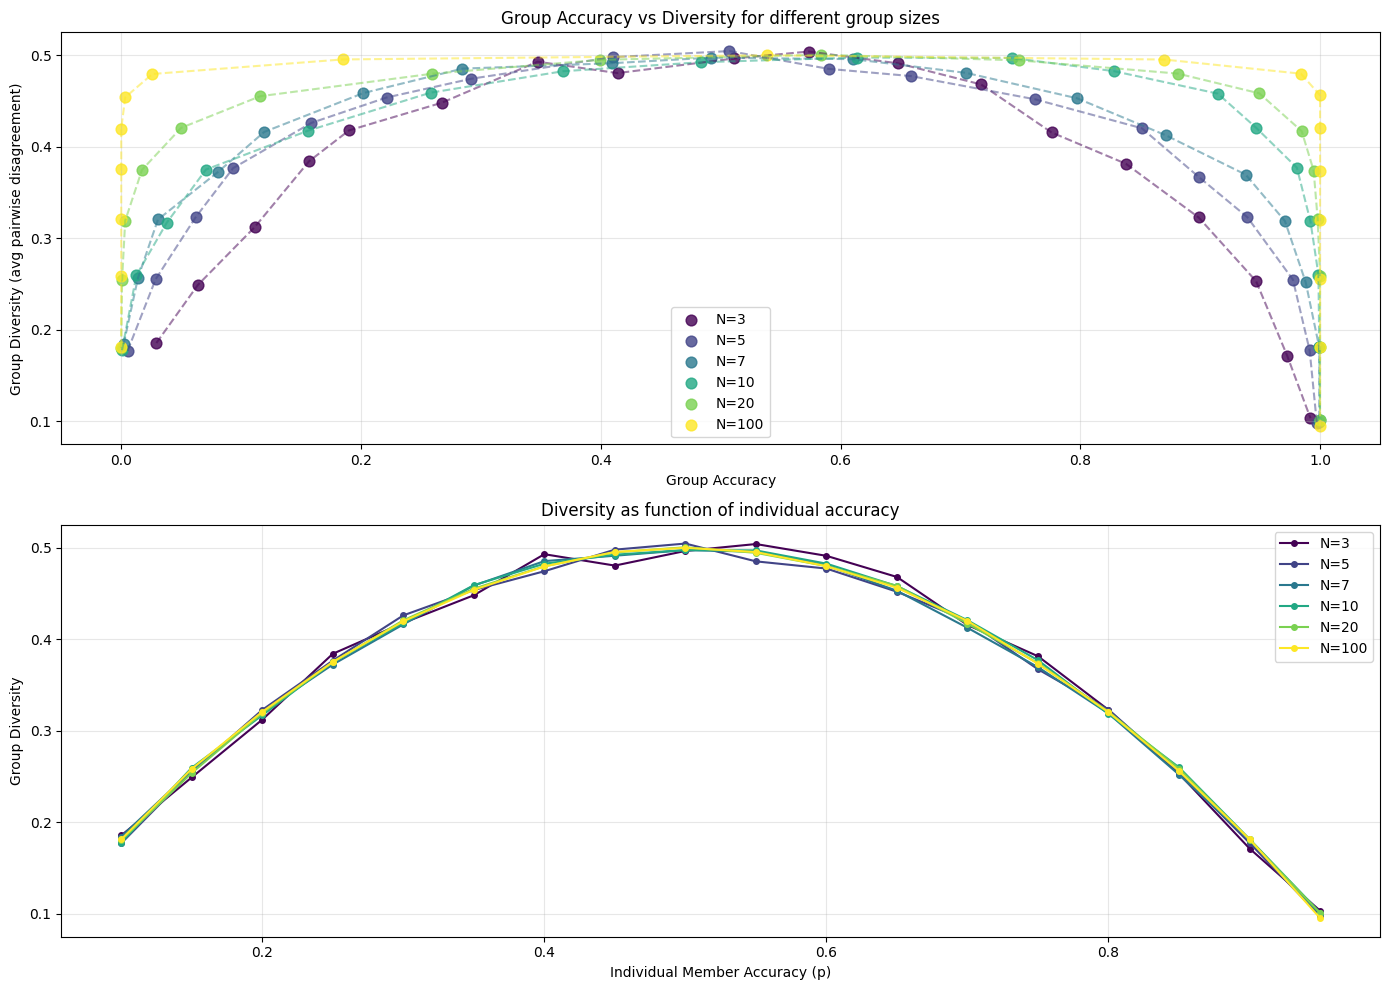

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm  # for progress bar (optional but nice)

def simulate_group(N, p_correct, A=2, num_simulations=2000, seed=None):
    """
    Simulate one group configuration.
    Returns: group_accuracy, average_diversity
    """
    if seed is not None:
        np.random.seed(seed)

    correct_answer = 0  # Assume answer 0 is correct

    group_correct_count = 0
    total_disagreements = 0
    total_pairs = N * (N - 1) // 2

    for _ in range(num_simulations):
        # Generate answers for all members
        answers = np.zeros(N, dtype=int)
        for i in range(N):
            if np.random.rand() < p_correct:
                answers[i] = correct_answer
            else:
                # Random wrong answer
                answers[i] = np.random.randint(1, A)

        # Majority vote for group decision
        counts = np.bincount(answers, minlength=A)
        majority_answer = np.argmax(counts)
        if majority_answer == correct_answer:
            group_correct_count += 1

        # Pairwise disagreements for diversity
        disagree_count = 0
        for i, j in combinations(range(N), 2):
            if answers[i] != answers[j]:
                disagree_count += 1
        total_disagreements += disagree_count

    group_accuracy = group_correct_count / num_simulations
    avg_diversity = total_disagreements / (num_simulations * total_pairs) if total_pairs > 0 else 0.0

    return group_accuracy, avg_diversity


# ====================== Generate data for graphs ======================
def run_simulations(N_values=[3, 5, 10, 20], p_values=None, A=10, num_sim=1000):
    if p_values is None:
        p_values = np.linspace(0.1, 0.95, 18)

    results = {}

    print("Running simulations...")
    for N in tqdm(N_values):
        group_accs = []
        diversities = []
        for p in p_values:
            g_acc, div = simulate_group(N, p, A=A, num_simulations=num_sim)
            group_accs.append(g_acc)
            diversities.append(div)
        results[N] = {
            'p': p_values,
            'group_accuracy': np.array(group_accs),
            'diversity': np.array(diversities)
        }
    return results


# ====================== Plotting ======================
def plot_graphs(results):
    plt.figure(figsize=(14, 10))

    # Graph 1: Group accuracy vs Diversity for different N
    plt.subplot(2, 1, 1)
    colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
    for i, (N, data) in enumerate(results.items()):
        plt.scatter(data['group_accuracy'], data['diversity'],
                   label=f'N={N}', color=colors[i], alpha=0.8, s=60)
        # Connect points for each N
        plt.plot(data['group_accuracy'], data['diversity'],
                color=colors[i], alpha=0.5, linestyle='--')

    plt.xlabel('Group Accuracy')
    plt.ylabel('Group Diversity (avg pairwise disagreement)')
    plt.title('Group Accuracy vs Diversity for different group sizes')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Graph 2: Maximum diversity as function of member accuracy (p)
    plt.subplot(2, 1, 2)
    for i, (N, data) in enumerate(results.items()):
        plt.plot(data['p'], data['diversity'],
                label=f'N={N}', color=colors[i], marker='o', markersize=4)

    plt.xlabel('Individual Member Accuracy (p)')
    plt.ylabel('Group Diversity')
    plt.title('Diversity as function of individual accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ====================== Run everything ======================
if __name__ == "__main__":
    # You can adjust these parameters
    N_values = [3, 5, 7, 10, 20, 100]
    A = 2                    # number of answer choices
    num_sim_per_point = 1500  # increase for smoother curves (slower)

    results = run_simulations(N_values=N_values, A=A, num_sim=num_sim_per_point)
    plot_graphs(results)

    # Optional: save results
    # import pickle
    # with open('simulation_results.pkl', 'wb') as f:
    #     pickle.dump(results, f)